# NovaRetail Sales Analysis with SQL and Pandas

## tl;dr

This beginner-friendly project analyzes a fictional electronics retailer using four synthetic CSV files, SQL, and Pandas.

- Sales increased from **$2.05M in 2023 to $2.56M in 2025**, a 25.2% increase.
- **Laptops and phones generated 62.9% of total sales**, but smaller categories had higher estimated product margins.
- Online was the largest channel at **48.8% of total sales**.
- The highest-spending customer quartile generated **56.2% of sales**.

**Business recommendation:** protect growth by improving online shopping, bundling high-margin accessories with laptops and phones, and creating a loyalty campaign for high-value customers.

> All data in this notebook is synthetic and describes a fictional company.

## Context & Methods

NovaRetail sells consumer electronics through Online, Store, and Pickup channels. Management wants a simple analysis of sales growth, product performance, channel mix, and customer value.

We will:

1. Load and clean four CSV files with Pandas.
2. Put the cleaned tables into an in-memory SQLite database.
3. Run SQL queries using joins, CTEs, window functions, and aggregations.
4. Visualize each result with Pandas plotting.

### Key assumptions

- Cancelled orders are excluded from sales.
- Net sales equal `quantity × unit price × (1 − discount)`.
- Estimated product margin subtracts product cost only; it is not full company profit.
- Because the data is synthetic, recommendations demonstrate analytical reasoning rather than real-company advice.

## Data

The project uses four related tables:

| Table | Grain | Purpose |
|---|---|---|
| `customers.csv` | One row per customer | Region, loyalty tier, and acquisition channel |
| `orders.csv` | One row per order | Date, customer, channel, and status |
| `order_items.csv` | One row per product in an order | Quantity, price, and discount |
| `products.csv` | One row per product | Category, brand, price, and product cost |

In [1]:
# 1. Import the libraries
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", 20)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    raise FileNotFoundError("Open this notebook from the project folder so the data/ directory is available.")

DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

BLUE = '#2D6CDF'
GOLD = '#E6A700'

In [2]:
# 2. Load the CSV files
customers = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv")
products = pd.read_csv(DATA_DIR / "products.csv", parse_dates=["launch_date"])

dataset_summary = pd.DataFrame({
    "table": ["customers", "orders", "order_items", "products"],
    "rows": [len(customers), len(orders), len(order_items), len(products)],
    "columns": [customers.shape[1], orders.shape[1], order_items.shape[1], products.shape[1]],
})
dataset_summary

,table,rows,columns
0,customers,4000,9
1,orders,12125,8
2,order_items,21270,6
3,products,180,8


In [3]:
# 3. Clean a few realistic text and missing-value issues
customers = customers.drop_duplicates(subset="customer_id").copy()
orders = orders.drop_duplicates(subset="order_id").copy()

customers["region"] = customers["region"].str.strip().str.title()
customers["loyalty_tier"] = customers["loyalty_tier"].str.strip().str.title()
customers["city"] = customers["city"].fillna("Unknown")

orders["channel"] = orders["channel"].str.strip().str.title()
orders["order_status"] = (
    orders["order_status"]
    .str.strip()
    .str.lower()
    .replace({"complete": "completed"})
    .str.title()
)

quality_checks = pd.DataFrame({
    "check": [
        "Unique customer IDs",
        "Unique order IDs",
        "Missing customer IDs in orders",
        "Missing order IDs in order items",
        "Discounts outside 0 to 1",
    ],
    "result": [
        customers["customer_id"].is_unique,
        orders["order_id"].is_unique,
        (~orders["customer_id"].isin(customers["customer_id"])).sum(),
        (~order_items["order_id"].isin(orders["order_id"])).sum(),
        (~order_items["discount_pct"].between(0, 1)).sum(),
    ],
})
quality_checks

,check,result
0,Unique customer IDs,True
1,Unique order IDs,True
2,Missing customer IDs in orders,0
3,Missing order IDs in order items,0
4,Discounts outside 0 to 1,0


In [4]:
# 4. Create a temporary SQLite database and load the Pandas DataFrames
connection = sqlite3.connect(":memory:")

customers.to_sql("customers", connection, index=False, if_exists="replace")
orders.to_sql("orders", connection, index=False, if_exists="replace")
order_items.to_sql("order_items", connection, index=False, if_exists="replace")
products.to_sql("products", connection, index=False, if_exists="replace")

print("Tables loaded into SQLite successfully.")

Tables loaded into SQLite successfully.


## Results

### Question 1: How have monthly sales changed?

This query uses a CTE, aggregation, and the `LAG` window function. `LAG` lets us compare each month with the previous month without joining the table to itself.

In [5]:
monthly_sales_sql = """
WITH monthly_sales AS (
    SELECT
        STRFTIME('%Y-%m-01', o.order_date) AS order_month,
        COUNT(DISTINCT o.order_id) AS orders,
        ROUND(SUM(oi.quantity * oi.unit_price * (1 - oi.discount_pct)), 2) AS net_sales
    FROM orders AS o
    JOIN order_items AS oi
        ON o.order_id = oi.order_id
    WHERE o.order_status <> 'Cancelled'
    GROUP BY STRFTIME('%Y-%m-01', o.order_date)
)
SELECT
    order_month,
    orders,
    net_sales,
    ROUND(
        100.0 * (net_sales / LAG(net_sales) OVER (ORDER BY order_month) - 1),
        1
    ) AS month_over_month_pct
FROM monthly_sales
ORDER BY order_month;
"""

monthly_sales = pd.read_sql_query(monthly_sales_sql, connection)
monthly_sales["order_month"] = pd.to_datetime(monthly_sales["order_month"])
monthly_sales.tail(8)

,order_month,orders,net_sales,month_over_month_pct
28,2025-05-01,322,208390.19,-5.0
29,2025-06-01,325,180407.95,-13.4
30,2025-07-01,302,165699.54,-8.2
31,2025-08-01,340,210696.96,27.2
32,2025-09-01,365,237666.91,12.8
33,2025-10-01,357,211543.35,-11.0
34,2025-11-01,550,298833.11,41.3
35,2025-12-01,584,315292.17,5.5


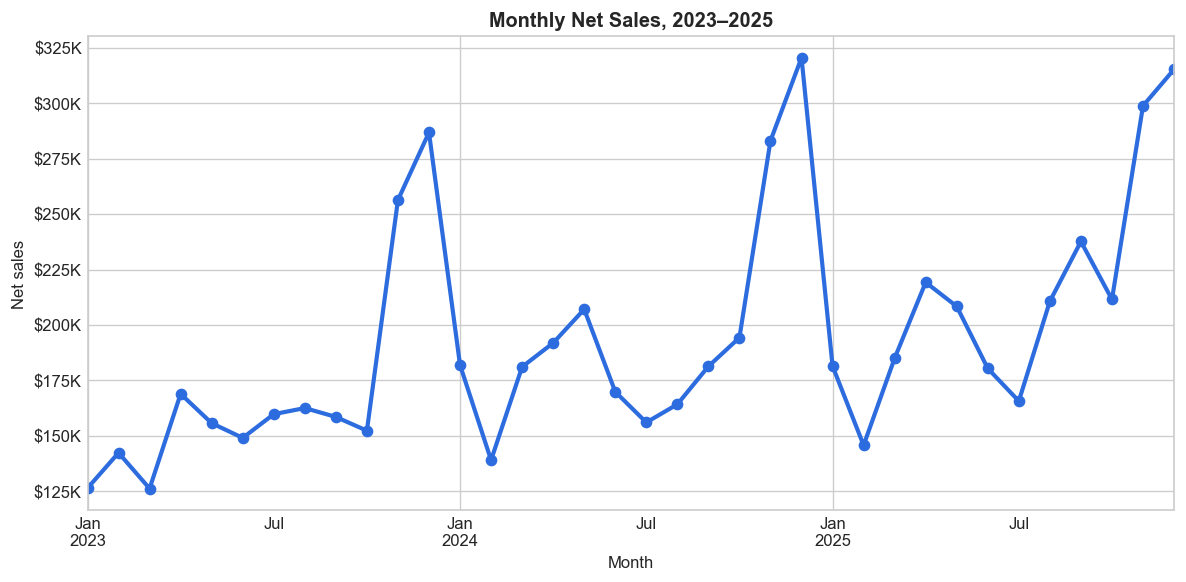

In [6]:
ax = monthly_sales.plot(
    x="order_month",
    y="net_sales",
    kind="line",
    figsize=(10, 5),
    color=BLUE,
    linewidth=2.5,
    marker="o",
    legend=False,
)
ax.set_title("Monthly Net Sales, 2023–2025", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Net sales")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value / 1000:,.0f}K"))
plt.tight_layout()
plt.savefig(FIGURE_DIR / "monthly_sales.png", dpi=150, bbox_inches="tight")
plt.show()

Annual sales increased from **$2.05M in 2023 to $2.56M in 2025**. The chart also shows holiday peaks near the end of each year. A business should compare holiday staffing and inventory plans with these recurring peaks.

### Question 2: Which product categories drive sales and estimated margin?

This query joins three tables, aggregates category performance, and uses `DENSE_RANK` to rank categories by sales.

In [7]:
category_sql = """
WITH category_performance AS (
    SELECT
        p.category,
        ROUND(SUM(oi.quantity * oi.unit_price * (1 - oi.discount_pct)), 2) AS net_sales,
        ROUND(SUM(oi.quantity * p.unit_cost), 2) AS product_cost
    FROM orders AS o
    JOIN order_items AS oi
        ON o.order_id = oi.order_id
    JOIN products AS p
        ON oi.product_id = p.product_id
    WHERE o.order_status <> 'Cancelled'
    GROUP BY p.category
)
SELECT
    category,
    net_sales,
    ROUND(100.0 * (net_sales - product_cost) / net_sales, 1) AS estimated_margin_pct,
    DENSE_RANK() OVER (ORDER BY net_sales DESC) AS sales_rank
FROM category_performance
ORDER BY sales_rank;
"""

category_performance = pd.read_sql_query(category_sql, connection)
category_performance

,category,net_sales,estimated_margin_pct,sales_rank
0,Laptops,2342097.12,23.7,1
1,Phones,2044274.94,29.2,2
2,Gaming,1002623.84,32.2,3
3,Audio,706907.51,43.0,4
4,Smart Home,531483.52,49.1,5
5,Accessories,348716.35,63.6,6


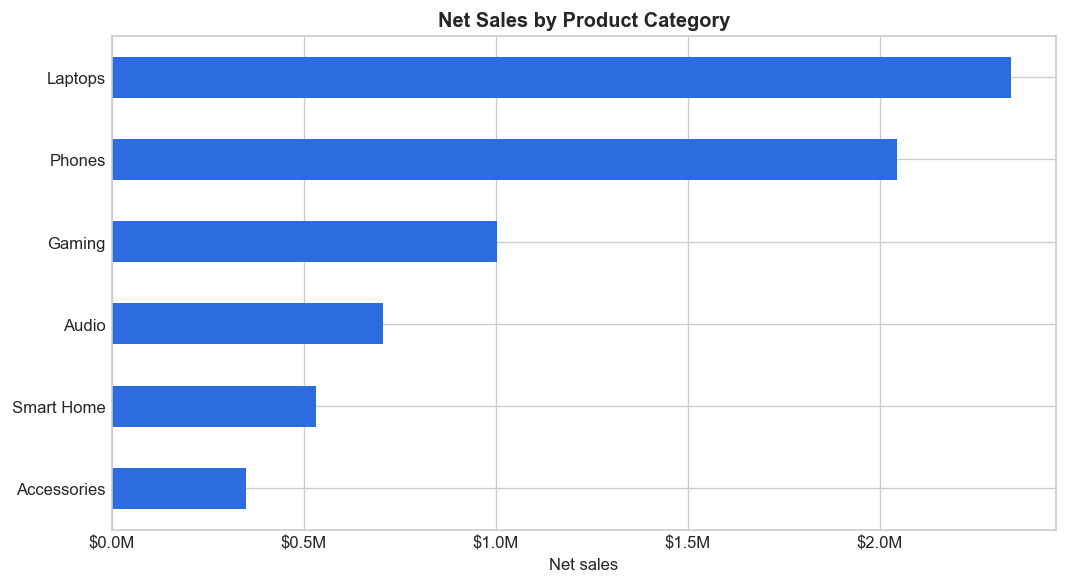

In [8]:
plot_data = category_performance.sort_values("net_sales")
ax = plot_data.plot(
    x="category",
    y="net_sales",
    kind="barh",
    figsize=(9, 5),
    color=BLUE,
    legend=False,
)
ax.set_title("Net Sales by Product Category", fontweight="bold")
ax.set_xlabel("Net sales")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value / 1_000_000:.1f}M"))
plt.tight_layout()
plt.savefig(FIGURE_DIR / "category_sales.png", dpi=150, bbox_inches="tight")
plt.show()

Laptops and phones produced **62.9% of total net sales**, but their estimated product margins were lower than those of smaller categories. NovaRetail could test bundles that add accessories to device purchases instead of discounting the main device further.

### Question 3: Which sales channel is largest?

This query uses conditional aggregation to compare channel sales by year.

In [9]:
channel_sql = """
SELECT
    STRFTIME('%Y', o.order_date) AS sales_year,
    o.channel,
    ROUND(SUM(oi.quantity * oi.unit_price * (1 - oi.discount_pct)), 2) AS net_sales
FROM orders AS o
JOIN order_items AS oi
    ON o.order_id = oi.order_id
WHERE o.order_status <> 'Cancelled'
GROUP BY STRFTIME('%Y', o.order_date), o.channel
ORDER BY sales_year, net_sales DESC;
"""

channel_sales = pd.read_sql_query(channel_sql, connection)
channel_pivot = channel_sales.pivot(index="sales_year", columns="channel", values="net_sales")
channel_pivot

channel,Online,Pickup,Store
sales_year,,,
2023,898564.80,314987.16,831769.26
2024,1140871.36,295966.40,933835.48
2025,1363738.65,307871.74,888498.43


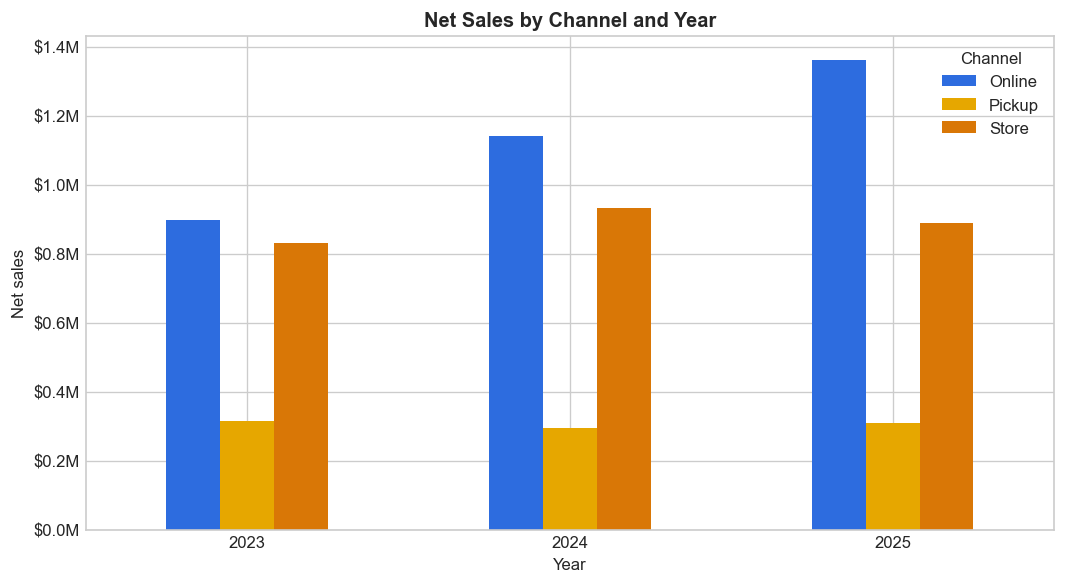

In [10]:
ax = channel_pivot.plot(
    kind="bar",
    figsize=(9, 5),
    color=[BLUE, GOLD, "#D97706"],
)
ax.set_title("Net Sales by Channel and Year", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Net sales")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value / 1_000_000:.1f}M"))
ax.legend(title="Channel", frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "channel_sales.png", dpi=150, bbox_inches="tight")
plt.show()

Online generated **48.8% of total sales**, making it the largest channel. Its growth suggests that website experience, delivery, and digital customer support should be priorities.

### Question 4: How concentrated is customer value?

This query calculates sales per customer and uses `NTILE(4)` to place customers into spending quartiles.

In [11]:
customer_sql = """
WITH customer_sales AS (
    SELECT
        o.customer_id,
        COUNT(DISTINCT o.order_id) AS orders,
        ROUND(SUM(oi.quantity * oi.unit_price * (1 - oi.discount_pct)), 2) AS net_sales
    FROM orders AS o
    JOIN order_items AS oi
        ON o.order_id = oi.order_id
    WHERE o.order_status <> 'Cancelled'
    GROUP BY o.customer_id
), customer_quartiles AS (
    SELECT
        *,
        NTILE(4) OVER (ORDER BY net_sales) AS spend_quartile
    FROM customer_sales
)
SELECT
    spend_quartile,
    COUNT(*) AS customers,
    ROUND(AVG(net_sales), 2) AS average_customer_sales,
    ROUND(SUM(net_sales), 2) AS total_sales
FROM customer_quartiles
GROUP BY spend_quartile
ORDER BY spend_quartile;
"""

customer_quartiles = pd.read_sql_query(customer_sql, connection)
customer_quartiles["sales_share_pct"] = (
    100 * customer_quartiles["total_sales"] / customer_quartiles["total_sales"].sum()
).round(1)
customer_quartiles

,spend_quartile,customers,average_customer_sales,total_sales,sales_share_pct
0,1,855,291.96,249627.37,3.6
1,2,855,1097.30,938191.49,13.4
2,3,855,2188.04,1870776.56,26.8
3,4,854,4587.25,3917508.22,56.2


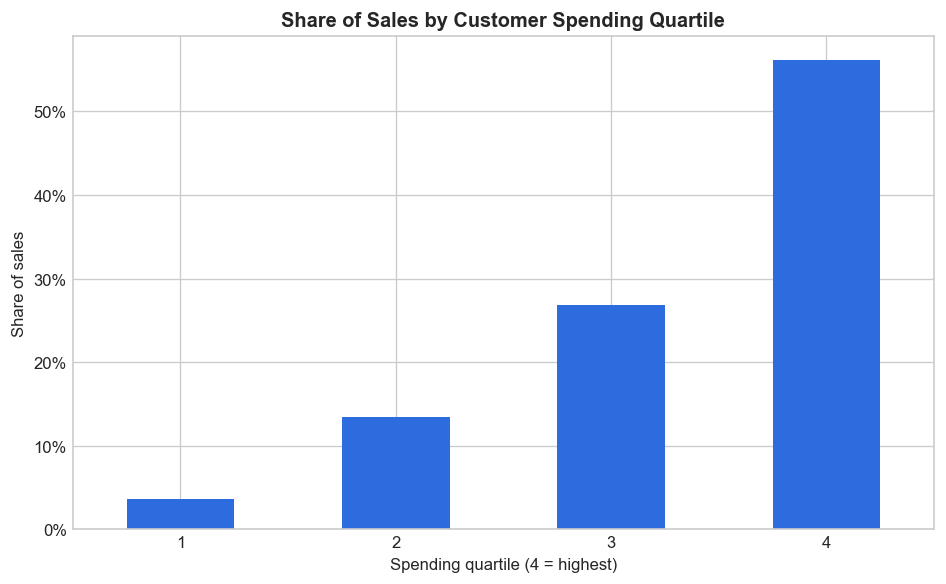

In [12]:
ax = customer_quartiles.plot(
    x="spend_quartile",
    y="sales_share_pct",
    kind="bar",
    figsize=(8, 5),
    color=BLUE,
    legend=False,
)
ax.set_title("Share of Sales by Customer Spending Quartile", fontweight="bold")
ax.set_xlabel("Spending quartile (4 = highest)")
ax.set_ylabel("Share of sales")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0f}%")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "customer_quartiles.png", dpi=150, bbox_inches="tight")
plt.show()

The highest-spending customer quartile generated **56.2% of sales**. A loyalty or early-access program may protect this valuable group, while the lower quartiles could receive lower-cost nurture campaigns.

## Checks

Before drawing conclusions, reconcile the SQL revenue calculation with the same formula in Pandas.

In [13]:
# Recalculate sales independently in Pandas
valid_orders = orders.loc[orders["order_status"] != "Cancelled", ["order_id"]]
pandas_check = (
    order_items.merge(valid_orders, on="order_id", how="inner")
    .assign(net_sales=lambda frame: frame["quantity"] * frame["unit_price"] * (1 - frame["discount_pct"]))
    ["net_sales"]
    .sum()
)
sql_check = monthly_sales["net_sales"].sum()

validation = pd.DataFrame({
    "calculation": ["SQL total sales", "Pandas total sales", "difference"],
    "value": [sql_check, pandas_check, sql_check - pandas_check],
})
validation

,calculation,value
0,SQL total sales,6.976103e+06
1,Pandas total sales,6.976103e+06
2,difference,1.450000e-02


The SQL and Pandas totals reconcile within normal currency-rounding precision. The earlier data-quality checks also confirm unique keys, valid discounts, and no broken order-item joins.

## Takeaways

1. **Sales are growing:** 2025 sales were 25.2% higher than 2023 sales.
2. **Core devices drive revenue:** laptops and phones produced nearly two-thirds of sales.
3. **Smaller categories support margin:** accessories and smart-home items had higher estimated product-margin percentages.
4. **Online is strategically important:** it was the largest channel and should receive continued experience and fulfillment investment.
5. **Customer value is concentrated:** the highest spending quartile generated more than half of sales.

### Recommended next step

Test a loyalty offer that bundles accessories with laptop or phone purchases for high-value online customers. Measure order value and estimated product margin against a comparison group.

### Limitations

- The dataset is synthetic.
- Estimated margin does not include shipping, labor, payment fees, or fixed costs.
- This analysis describes patterns and does not prove that a particular action caused them.